In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv("../data/github_repo_dataset.csv")

In [4]:
df.head()

,repository,language,description,stars,forks,open_issues,contributors,created_at,pushed_at,size_kb,license,status,project_age_days,days_since_last_push
0,nvbn/thefuck,Python,Magnificent app which corrects your previous c...,94098,3767,393,166,2015-04-08,2024-07-19,4043,MIT License,Active,3823,433
1,3b1b/manim,Python,Animation engine for explanatory math videos,80734,6886,472,165,2015-03-22,2025-06-14,76584,MIT License,Active,3840,103
2,keras-team/keras,Python,Deep Learning for humans,63426,19627,265,405,2015-03-28,2025-09-24,47953,Apache License 2.0,Active,3834,1
3,charlax/professional-programming,Python,A collection of learning resources for curious...,48597,3856,2,35,2015-11-07,2025-09-22,4914,MIT License,Active,3610,3
4,minimaxir/big-list-of-naughty-strings,Python,The Big List of Naughty Strings is a list of s...,47422,2158,108,67,2015-08-08,2024-04-18,330,MIT License,Active,3701,525


In [5]:
df.shape

(46201, 14)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46201 entries, 0 to 46200
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   repository            46201 non-null  str  
 1   language              46178 non-null  str  
 2   description           44706 non-null  str  
 3   stars                 46201 non-null  int64
 4   forks                 46201 non-null  int64
 5   open_issues           46201 non-null  int64
 6   contributors          46201 non-null  int64
 7   created_at            46201 non-null  str  
 8   pushed_at             46201 non-null  str  
 9   size_kb               46201 non-null  int64
 10  license               38833 non-null  str  
 11  status                46201 non-null  str  
 12  project_age_days      46201 non-null  int64
 13  days_since_last_push  46201 non-null  int64
dtypes: int64(7), str(7)
memory usage: 11.5 MB


In [7]:
df.describe()

,stars,forks,open_issues,contributors,size_kb,project_age_days,days_since_last_push
count,46201.000000,46201.000000,46201.000000,46201.000000,4.620100e+04,46201.000000,46201.000000
mean,1944.437133,327.979697,57.611134,26.234216,6.689389e+04,2439.622974,654.548278
std,5697.593993,1155.484893,250.435886,56.359496,7.159548e+05,834.142832,769.285173
min,101.000000,0.000000,0.000000,0.000000,0.000000e+00,999.000000,0.000000
25%,366.000000,50.000000,5.000000,2.000000,6.920000e+02,1713.000000,30.000000
50%,764.000000,117.000000,16.000000,7.000000,4.225000e+03,2421.000000,408.000000
75%,1616.000000,273.000000,46.000000,23.000000,2.471400e+04,3150.000000,993.000000
max,366224.000000,74883.000000,26590.000000,485.000000,1.011714e+08,3920.000000,3916.000000


In [8]:
threshold = df["stars"].quantile(0.80)

print(threshold)

1983.0


In [9]:
df["adoption"] = np.where(
    df["stars"] >= threshold,
    "High Adoption",
    "Low Adoption"
)

In [10]:
df["adoption"].value_counts()

adoption
Low Adoption     36958
High Adoption     9243
Name: count, dtype: int64

In [11]:
df[["stars", "adoption"]].head(10)

,stars,adoption
0,94098,High Adoption
1,80734,High Adoption
2,63426,High Adoption
3,48597,High Adoption
4,47422,High Adoption
5,42556,High Adoption
6,33319,High Adoption
7,32466,High Adoption
8,31344,High Adoption
9,30776,High Adoption


In [12]:
df["adoption"].value_counts()

adoption
Low Adoption     36958
High Adoption     9243
Name: count, dtype: int64

In [13]:
df[["stars", "adoption"]].head(10)

,stars,adoption
0,94098,High Adoption
1,80734,High Adoption
2,63426,High Adoption
3,48597,High Adoption
4,47422,High Adoption
5,42556,High Adoption
6,33319,High Adoption
7,32466,High Adoption
8,31344,High Adoption
9,30776,High Adoption


In [14]:
df = df.drop(
    columns=[
        "repository",
        "description",
        "created_at",
        "pushed_at",
        "status",
        "stars"
    ]
)

In [15]:
df.columns

Index(['language', 'forks', 'open_issues', 'contributors', 'size_kb',
       'license', 'project_age_days', 'days_since_last_push', 'adoption'],
      dtype='str')

In [16]:
print(df.columns.tolist())

['language', 'forks', 'open_issues', 'contributors', 'size_kb', 'license', 'project_age_days', 'days_since_last_push', 'adoption']


In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/github_repo_dataset.csv")

In [18]:
df.shape


(46201, 14)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46201 entries, 0 to 46200
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   repository            46201 non-null  str  
 1   language              46178 non-null  str  
 2   description           44706 non-null  str  
 3   stars                 46201 non-null  int64
 4   forks                 46201 non-null  int64
 5   open_issues           46201 non-null  int64
 6   contributors          46201 non-null  int64
 7   created_at            46201 non-null  str  
 8   pushed_at             46201 non-null  str  
 9   size_kb               46201 non-null  int64
 10  license               38833 non-null  str  
 11  status                46201 non-null  str  
 12  project_age_days      46201 non-null  int64
 13  days_since_last_push  46201 non-null  int64
dtypes: int64(7), str(7)
memory usage: 11.5 MB


In [20]:
df["language"] = df["language"].fillna("Unknown")
df["description"] = df["description"].fillna("")
df["license"] = df["license"].fillna("No License")

In [21]:
df.isnull().sum()   

repository              0
language                0
description             0
stars                   0
forks                   0
open_issues             0
contributors            0
created_at              0
pushed_at               0
size_kb                 0
license                 0
status                  0
project_age_days        0
days_since_last_push    0
dtype: int64

In [22]:
threshold = df["stars"].quantile(0.80)

print("80th Percentile:", threshold)

80th Percentile: 1983.0


In [23]:
df["adoption"] = np.where(
    df["stars"] >= threshold,
    "High Adoption",
    "Low Adoption"
)

In [24]:
df["adoption"].value_counts()

adoption
Low Adoption     36958
High Adoption     9243
Name: count, dtype: int64

In [25]:
df["description_length"] = df["description"].str.len()

In [26]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["pushed_at"] = pd.to_datetime(df["pushed_at"])

In [27]:
df["created_year"] = df["created_at"].dt.year

df["pushed_year"] = df["pushed_at"].dt.year

In [28]:
df[[
    "description_length",
    "created_year",
    "pushed_year"
]].head()

,description_length,created_year,pushed_year
0,61,2015,2024
1,44,2015,2025
2,24,2015,2025
3,65,2015,2025
4,130,2015,2024


In [29]:
df = df.drop(columns=[
    "repository",
    "description",
    "created_at",
    "pushed_at",
    "status",
    "stars"
])

In [30]:
print(df.columns.tolist())

['language', 'forks', 'open_issues', 'contributors', 'size_kb', 'license', 'project_age_days', 'days_since_last_push', 'adoption', 'description_length', 'created_year', 'pushed_year']


In [31]:
from sklearn.preprocessing import LabelEncoder

language_encoder = LabelEncoder()
license_encoder = LabelEncoder()
adoption_encoder = LabelEncoder()

df["language"] = language_encoder.fit_transform(df["language"])
df["license"] = license_encoder.fit_transform(df["license"])
df["adoption"] = adoption_encoder.fit_transform(df["adoption"])

In [32]:
df.head()


,language,forks,open_issues,contributors,size_kb,license,project_age_days,days_since_last_push,adoption,description_length,created_year,pushed_year
0,4,3767,393,166,4043,25,3823,433,0,61,2015,2024
1,4,6886,472,165,76584,25,3840,103,0,44,2015,2025
2,4,19627,265,405,47953,0,3834,1,0,24,2015,2025
3,4,3856,2,35,4914,25,3610,3,0,65,2015,2025
4,4,2158,108,67,330,25,3701,525,0,130,2015,2024


In [33]:
X = df.drop("adoption", axis=1)

y = df["adoption"]

In [34]:
print(X.shape)

print(y.shape)

(46201, 11)
(46201,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)

(36960, 11)
(9241, 11)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [38]:
print(X_train.shape)
print(X_test.shape)

(36960, 11)
(9241, 11)


In [39]:
X_train[:5]

array([[-0.24996398, -0.21689587,  0.05981708,  0.21108878, -0.08667838,
        -1.62901364, -1.00808895, -0.84809121, -0.05493983,  1.07179865,
         0.7735608 ],
       [-0.24996398, -0.25131475, -0.22900966, -0.33973687, -0.08786268,
        -1.37733107, -0.84261587, -0.12039493, -0.01354819,  0.63168579,
         0.29195841],
       [ 0.94289187,  5.74844069, -0.16925241, -0.2686626 , -0.07599634,
         0.8878121 ,  0.43080739, -0.84159392, -0.1111142 , -0.24853992,
         0.7735608 ],
       [-0.24996398, -0.03936687, -0.16427263, -0.07320833, -0.09321193,
         0.46834114,  1.21620497,  0.83340698, -0.10224456, -1.12876564,
        -0.67124635],
       [-0.8463919 , -0.20330946, -0.07463675, -0.01990262, -0.08901405,
        -1.62901364,  0.6670262 , -0.64017798, -0.06085292, -0.68865278,
         0.7735608 ]])

In [40]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [41]:
y_pred_lr = lr_model.predict(X_test)

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision :", precision_score(y_test, y_pred_lr))
print("Recall :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.8631100530245644
Precision : 0.869770253929867
Recall : 0.9745291965858285
F1 Score : 0.9191744936425787


In [43]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.42      0.55      1860
           1       0.87      0.97      0.92      7381

    accuracy                           0.86      9241
   macro avg       0.84      0.70      0.74      9241
weighted avg       0.86      0.86      0.85      9241



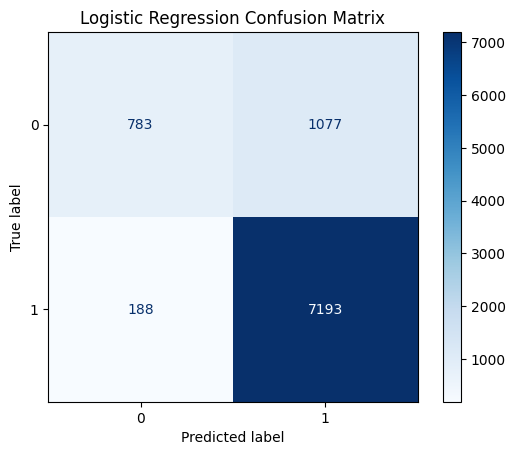

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    knn_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

# Save the image
plt.savefig("../images/logistic_regression_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

# Show the image
plt.show()

NameError: name 'knn_model' is not defined

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
y_pred_knn = knn_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision :", precision_score(y_test, y_pred_knn))
print("Recall :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

Accuracy : 0.8588897305486419
Precision : 0.8806213203056495
Recall : 0.9524454680937542
F1 Score : 0.9151262692007289


In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.72      0.49      0.58      1860
           1       0.88      0.95      0.92      7381

    accuracy                           0.86      9241
   macro avg       0.80      0.72      0.75      9241
weighted avg       0.85      0.86      0.85      9241



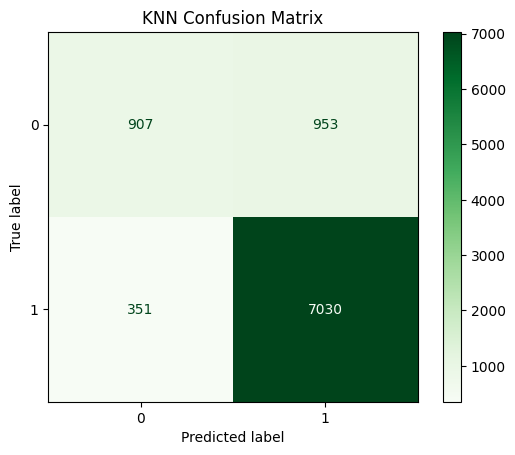

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    knn_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("KNN Confusion Matrix")
plt.show()

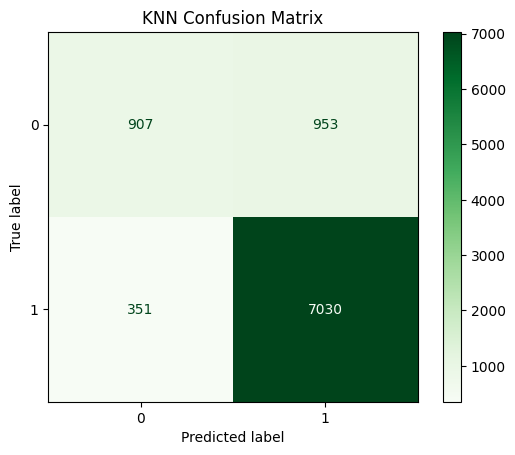

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    knn_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("KNN Confusion Matrix")

# Save the image
plt.savefig("../images/knn_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

# Show the image
plt.show()

In [ ]:
from lightgbm import LGBMClassifier

In [ ]:
lgbm_model = LGBMClassifier(random_state=42)

In [ ]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 29577, number of negative: 7383
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1845
[LightGBM] [Info] Number of data points in the train set: 36960, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.800244 -> initscore=1.387817
[LightGBM] [Info] Start training from score 1.387817


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [ ]:
y_pred_lgbm = lgbm_model.predict(X_test)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision :", precision_score(y_test, y_pred_lgbm))
print("Recall :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))

Accuracy : 0.8874580673087328
Precision : 0.9116997792494481
Recall : 0.9512261211217992
F1 Score : 0.9310436281660257


In [ ]:
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.77      0.63      0.69      1860
           1       0.91      0.95      0.93      7381

    accuracy                           0.89      9241
   macro avg       0.84      0.79      0.81      9241
weighted avg       0.88      0.89      0.88      9241



c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


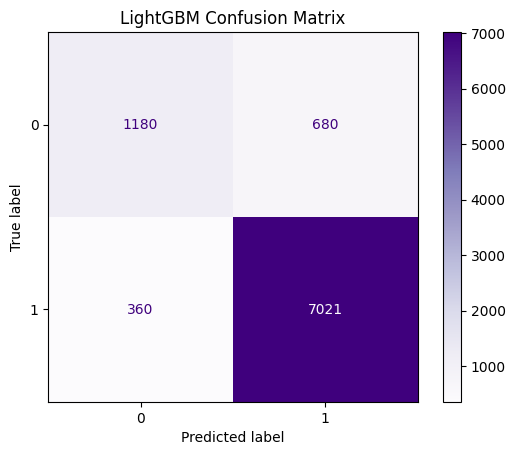

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    lgbm_model,
    X_test,
    y_test,
    cmap="Purples"
)

plt.title("LightGBM Confusion Matrix")
plt.show()

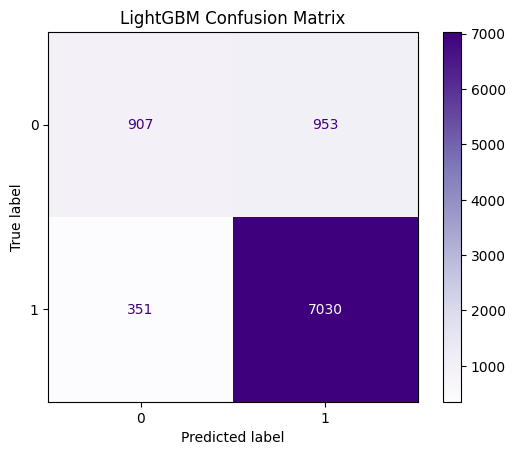

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    knn_model,
    X_test,
    y_test,
    cmap="Purples"
)

plt.title("LightGBM Confusion Matrix")

# Save the image
plt.savefig("../images/lightgbm_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

# Show the image
plt.show()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


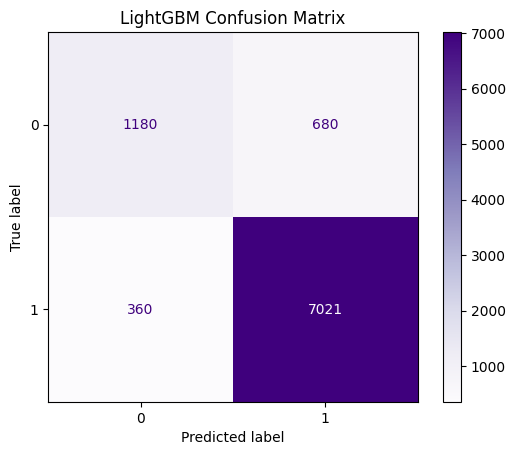

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    lgbm_model,
    X_test,
    y_test,
    cmap="Purples"
)

plt.title("LightGBM Confusion Matrix")

# Save the image
plt.savefig("../images/confusion_matrix.png", dpi=300, bbox_inches="tight")

# Display the image
plt.show()

In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

In [ ]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

In [ ]:
lgbm_accuracy = accuracy_score(y_test, y_pred_lgbm)
lgbm_precision = precision_score(y_test, y_pred_lgbm)
lgbm_recall = recall_score(y_test, y_pred_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm)

In [ ]:
results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "KNN",
        "LightGBM"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        lgbm_accuracy
    ],
    "Precision": [
        lr_precision,
        knn_precision,
        lgbm_precision
    ],
    "Recall": [
        lr_recall,
        knn_recall,
        lgbm_recall
    ],
    "F1 Score": [
        lr_f1,
        knn_f1,
        lgbm_f1
    ]
})

results

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.863110,0.869770,0.974529,0.919174
1,KNN,0.858890,0.880621,0.952445,0.915126
2,LightGBM,0.887458,0.911700,0.951226,0.931044


In [ ]:
import joblib

joblib.dump(lgbm_model, "../models/github_adoption_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(language_encoder, "../models/language_encoder.pkl")
joblib.dump(license_encoder, "../models/license_encoder.pkl")
joblib.dump(adoption_encoder, "../models/adoption_encoder.pkl")

['../models/adoption_encoder.pkl']

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,forks,535
6,project_age_days,363
3,contributors,358
2,open_issues,343
4,size_kb,327
8,description_length,303
7,days_since_last_push,301
0,language,283
5,license,173
9,created_year,9


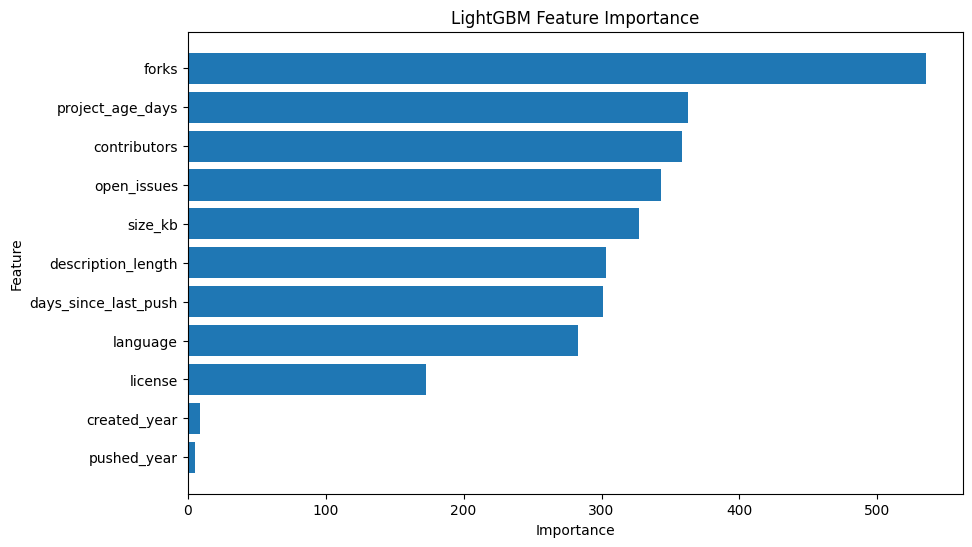

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance")

plt.gca().invert_yaxis()

plt.savefig("../images/feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
probabilities = lgbm_model.predict_proba(X_test)

print(probabilities[:5])

[[0.04431663 0.95568337]
 [0.00835584 0.99164416]
 [0.31659794 0.68340206]
 [0.05183086 0.94816914]
 [0.00499458 0.99500542]]


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
sample = X_test[0:1]

prediction = lgbm_model.predict(sample)
probability = lgbm_model.predict_proba(sample)

print("Predicted Class:", prediction)
print("Probability:", probability)

Predicted Class: [1]
Probability: [[0.04431663 0.95568337]]


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import os
import joblib

# Create the models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained LightGBM model
joblib.dump(lgbm_model, "../models/lightgbm_model.pkl")

# Save the StandardScaler
joblib.dump(scaler, "../models/scaler.pkl")

# Save the Label Encoders
joblib.dump(language_encoder, "../models/language_encoder.pkl")
joblib.dump(license_encoder, "../models/license_encoder.pkl")
joblib.dump(adoption_encoder, "../models/adoption_encoder.pkl")

print("✅ All models and preprocessing objects have been saved successfully!")

✅ All models and preprocessing objects have been saved successfully!


In [ ]:
# Create a DataFrame of feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
})

# Sort from highest to lowest importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the table
importance

,Feature,Importance
1,forks,535
6,project_age_days,363
3,contributors,358
2,open_issues,343
4,size_kb,327
8,description_length,303
7,days_since_last_push,301
0,language,283
5,license,173
9,created_year,9


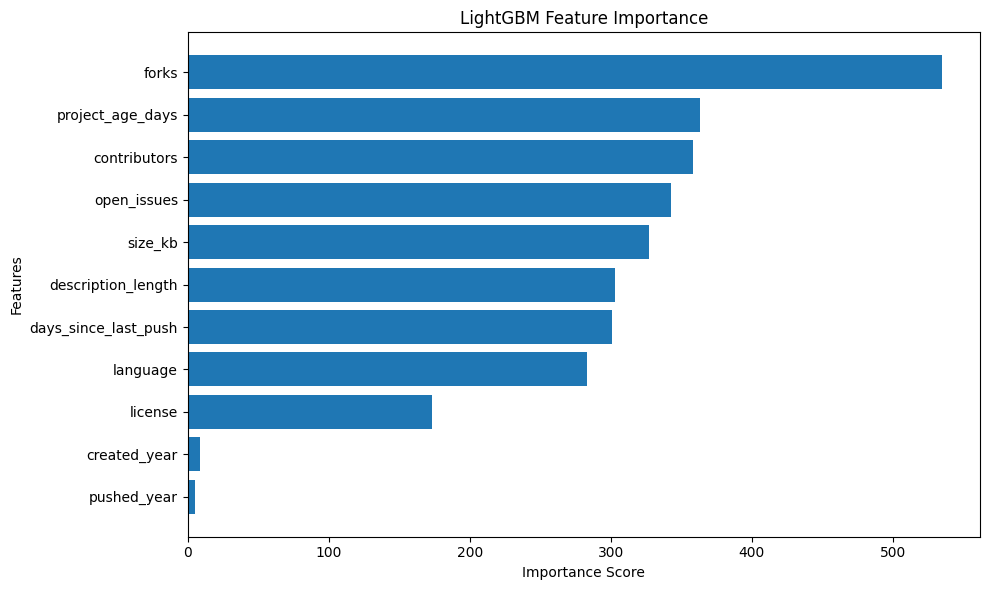

In [ ]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot horizontal bar chart
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

# Highest importance at the top
plt.gca().invert_yaxis()

# Add title and labels
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Adjust layout
plt.tight_layout()

# Save the graph
plt.savefig("../images/feature_importance.png", dpi=300)

# Display the graph
plt.show()

In [ ]:
# Take one repository from the test set
sample_input = X_test[0].reshape(1, -1)

# Predict the class
prediction = lgbm_model.predict(sample_input)

# Predict the probabilities
probabilities = lgbm_model.predict_proba(sample_input)

print("Prediction:", prediction)
print("Probabilities:", probabilities)

Prediction: [1]
Probabilities: [[0.04431663 0.95568337]]


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Convert prediction back to original label
predicted_label = adoption_encoder.inverse_transform(prediction)

# Get the highest probability
confidence = probabilities.max() * 100

print("Prediction :", predicted_label[0])
print(f"Confidence : {confidence:.2f}%")

Prediction : Low Adoption
Confidence : 95.57%


In [ ]:
import requests

In [ ]:
import requests

url = "https://api.github.com/repos/pallets/flask"

response = requests.get(url)

print(response.status_code)

200


In [ ]:
repo_data = response.json()

print(repo_data)

{'id': 596892, 'node_id': 'MDEwOlJlcG9zaXRvcnk1OTY4OTI=', 'name': 'flask', 'full_name': 'pallets/flask', 'private': False, 'owner': {'login': 'pallets', 'id': 16748505, 'node_id': 'MDEyOk9yZ2FuaXphdGlvbjE2NzQ4NTA1', 'avatar_url': 'https://avatars.githubusercontent.com/u/16748505?v=4', 'gravatar_id': '', 'url': 'https://api.github.com/users/pallets', 'html_url': 'https://github.com/pallets', 'followers_url': 'https://api.github.com/users/pallets/followers', 'following_url': 'https://api.github.com/users/pallets/following{/other_user}', 'gists_url': 'https://api.github.com/users/pallets/gists{/gist_id}', 'starred_url': 'https://api.github.com/users/pallets/starred{/owner}{/repo}', 'subscriptions_url': 'https://api.github.com/users/pallets/subscriptions', 'organizations_url': 'https://api.github.com/users/pallets/orgs', 'repos_url': 'https://api.github.com/users/pallets/repos', 'events_url': 'https://api.github.com/users/pallets/events{/privacy}', 'received_events_url': 'https://api.githu

In [ ]:
import requests

# User enters a GitHub repository URL
repo_url = input("Enter GitHub Repository URL: ")

# Remove extra "/" and split the URL
parts = repo_url.strip("/").split("/")

# Extract owner and repository name
owner = parts[-2]
repo = parts[-1]

# Build the GitHub API URL
api_url = f"https://api.github.com/repos/{owner}/{repo}"

# Fetch repository data
response = requests.get(api_url)

if response.status_code == 200:
    print("✅ Repository found!")
    repo_data = response.json()
else:
    print("❌ Repository not found!")

✅ Repository found!


In [ ]:
from datetime import datetime

# Extract values from the API response
language = repo_data["language"]

forks = repo_data["forks_count"]

open_issues = repo_data["open_issues_count"]

size_kb = repo_data["size"]

description = repo_data["description"] or ""

description_length = len(description)

license_name = (
    repo_data["license"]["name"]
    if repo_data["license"] is not None
    else "No License"
)

created_at = datetime.strptime(
    repo_data["created_at"],
    "%Y-%m-%dT%H:%M:%SZ"
)

pushed_at = datetime.strptime(
    repo_data["pushed_at"],
    "%Y-%m-%dT%H:%M:%SZ"
)

created_year = created_at.year

pushed_year = pushed_at.year

project_age_days = (datetime.now() - created_at).days

days_since_last_push = (datetime.now() - pushed_at).days

In [ ]:
print("Language:", language)
print("Forks:", forks)
print("Open Issues:", open_issues)
print("Size (KB):", size_kb)
print("License:", license_name)
print("Description Length:", description_length)
print("Created Year:", created_year)
print("Pushed Year:", pushed_year)
print("Project Age (Days):", project_age_days)
print("Days Since Last Push:", days_since_last_push)

Language: Python
Forks: 16898
Open Issues: 8
Size (KB): 12008
License: BSD 3-Clause "New" or "Revised" License
Description Length: 57
Created Year: 2010
Pushed Year: 2026
Project Age (Days): 5937
Days Since Last Push: 27


In [ ]:
# GitHub Contributors API
contributors_url = f"https://api.github.com/repos/{owner}/{repo}/contributors"

contributors_response = requests.get(contributors_url)

if contributors_response.status_code == 200:
    contributors = len(contributors_response.json())
else:
    contributors = 0

print("Contributors:", contributors)

Contributors: 30


In [ ]:
contributors = 0
page = 1

while True:

    contributors_url = (
        f"https://api.github.com/repos/{owner}/{repo}/contributors"
        f"?per_page=100&page={page}"
    )

    response = requests.get(contributors_url)

    data = response.json()

    if len(data) == 0:
        break

    contributors += len(data)

    page += 1

print("Total Contributors:", contributors)

Total Contributors: 400


In [ ]:
# Create input dictionary

repo_features = {
    "language": language,
    "forks": forks,
    "open_issues": open_issues,
    "contributors": contributors,
    "size_kb": size_kb,
    "license": license_name,
    "project_age_days": project_age_days,
    "days_since_last_push": days_since_last_push,
    "description_length": description_length,
    "created_year": created_year,
    "pushed_year": pushed_year
}


# Convert dictionary to DataFrame

new_repo_df = pd.DataFrame([repo_features])


# Display the data

new_repo_df

,language,forks,open_issues,contributors,size_kb,license,project_age_days,days_since_last_push,description_length,created_year,pushed_year
0,Python,16898,8,400,12008,"BSD 3-Clause ""New"" or ""Revised"" License",5937,27,57,2010,2026


In [ ]:
X.columns

Index(['language', 'forks', 'open_issues', 'contributors', 'size_kb',
       'license', 'project_age_days', 'days_since_last_push',
       'description_length', 'created_year', 'pushed_year'],
      dtype='str')

In [46]:
print(X.columns.tolist())

['language', 'forks', 'open_issues', 'contributors', 'size_kb', 'license', 'project_age_days', 'days_since_last_push', 'description_length', 'created_year', 'pushed_year']


In [47]:
print(language_encoder.classes_)

['C++' 'Go' 'Java' 'JavaScript' 'Python' 'Rust' 'Unknown']


In [48]:
print(license_encoder.classes_)

['Apache License 2.0' 'Artistic License 2.0'
 'BSD 2-Clause "Simplified" License'
 'BSD 3-Clause "New" or "Revised" License' 'BSD 3-Clause Clear License'
 'BSD 4-Clause "Original" or "Old" License' 'BSD Zero Clause License'
 'Boost Software License 1.0'
 'CERN Open Hardware Licence Version 2 - Strongly Reciprocal'
 'Creative Commons Attribution 4.0 International'
 'Creative Commons Attribution Share Alike 4.0 International'
 'Creative Commons Zero v1.0 Universal'
 'Do What The F*ck You Want To Public License'
 'Eclipse Public License 1.0' 'Eclipse Public License 2.0'
 'Educational Community License v2.0' 'European Union Public License 1.1'
 'European Union Public License 1.2'
 'GNU Affero General Public License v3.0'
 'GNU General Public License v2.0' 'GNU General Public License v3.0'
 'GNU Lesser General Public License v2.1'
 'GNU Lesser General Public License v3.0' 'ISC License'
 'LaTeX Project Public License v1.3c' 'MIT License' 'MIT No Attribution'
 'Microsoft Public License' 'Mozi

In [49]:
print(len(language_encoder.classes_))
print(len(license_encoder.classes_))

7
40


In [51]:
print("Unknown" in language_encoder.classes_)
print("No License" in license_encoder.classes_)

True
True
